# ChestXray Project Report


### CUSTOMCNN Metrics


,Label,AUROC,PR-AUC,F1,Precision,Recall
0,Atelectasis,0.642469,0.144280,0.117719,0.165803,0.091255
1,Cardiomegaly,0.754071,0.144686,0.128603,0.308511,0.081232
2,Effusion,0.726628,0.241772,0.283956,0.296059,0.272804
3,Infiltration,0.589341,0.234141,0.221370,0.264085,0.190549
4,Mass,0.613253,0.080361,0.058104,0.147287,0.036190
5,Nodule,0.559658,0.072830,0.062893,0.125628,0.041946
6,Pneumonia,0.599231,0.023681,0.028986,0.250000,0.015385
7,Pneumothorax,0.653303,0.089909,0.084142,0.176871,0.055202
8,Consolidation,0.645877,0.064087,0.035785,0.088235,0.022444
9,Edema,0.756444,0.066706,0.041494,0.142857,0.024272



### RESNET18 Metrics


,Label,AUROC,PR-AUC,F1,Precision,Recall
0,Atelectasis,0.739149,0.235080,0.268779,0.290608,0.250000
1,Cardiomegaly,0.865051,0.262593,0.333333,0.375439,0.299720
2,Effusion,0.825817,0.407872,0.418473,0.473348,0.375000
3,Infiltration,0.633054,0.271915,0.225470,0.357616,0.164634
4,Mass,0.753991,0.252424,0.291188,0.441860,0.217143
5,Nodule,0.655927,0.115050,0.133038,0.196078,0.100671
6,Pneumonia,0.640537,0.029248,0.032086,0.052632,0.023077
7,Pneumothorax,0.783545,0.226682,0.243759,0.395238,0.176221
8,Consolidation,0.696749,0.102215,0.071295,0.143939,0.047382
9,Edema,0.804646,0.105643,0.114114,0.149606,0.092233



### VGG19 Metrics


,Label,AUROC,PR-AUC,F1,Precision,Recall
0,Atelectasis,0.759260,0.263150,0.197461,0.382514,0.133080
1,Cardiomegaly,0.856053,0.279887,0.315236,0.420561,0.252101
2,Effusion,0.833576,0.429922,0.438180,0.528640,0.374155
3,Infiltration,0.674373,0.292957,0.112484,0.348285,0.067073
4,Mass,0.773672,0.265373,0.319428,0.426752,0.255238
5,Nodule,0.711720,0.182068,0.099561,0.390805,0.057047
6,Pneumonia,0.669289,0.026088,0.000000,0.000000,0.000000
7,Pneumothorax,0.821233,0.236448,0.241983,0.386047,0.176221
8,Consolidation,0.767967,0.110441,0.009709,0.181818,0.004988
9,Edema,0.796298,0.072739,0.024096,0.069767,0.014563



Customcnn Auroc Curve


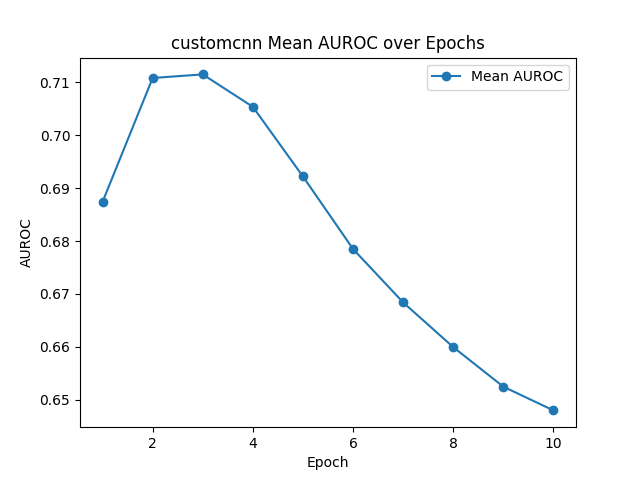


Customcnn F1 Curve


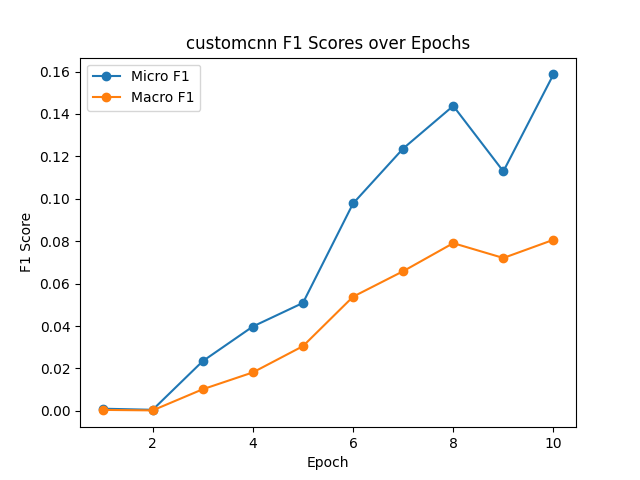


Customcnn Precision Curve


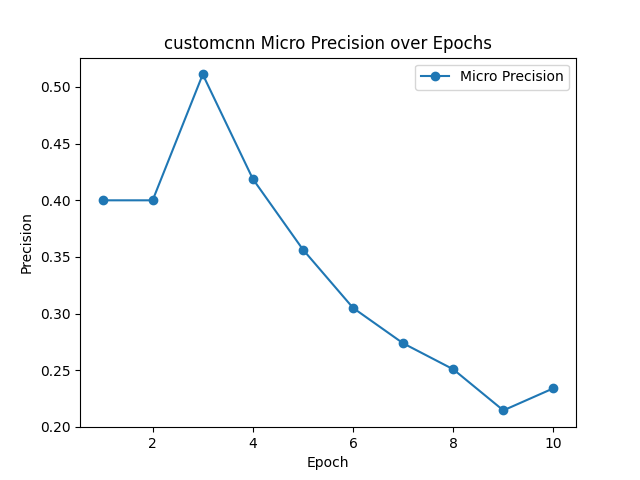


Customcnn Recall Curve


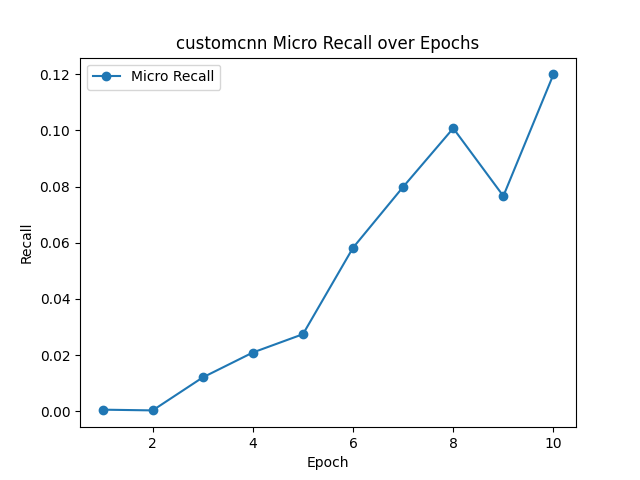


Resnet18 Auroc Curve


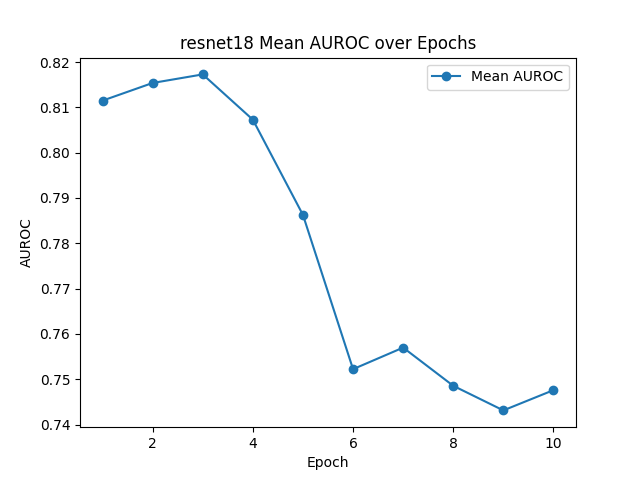


Resnet18 F1 Curve


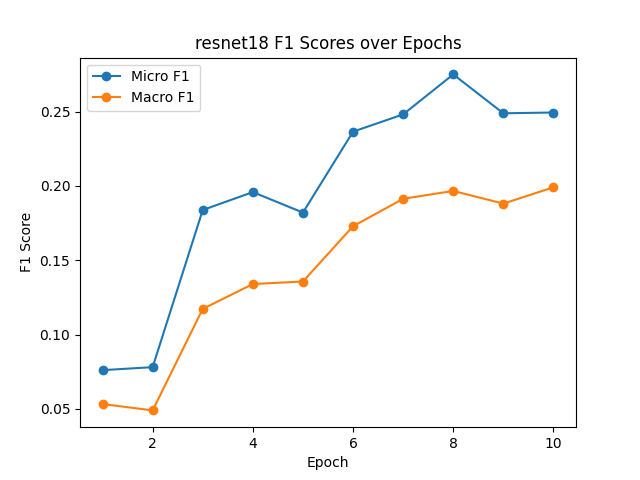


Resnet18 Precision Curve


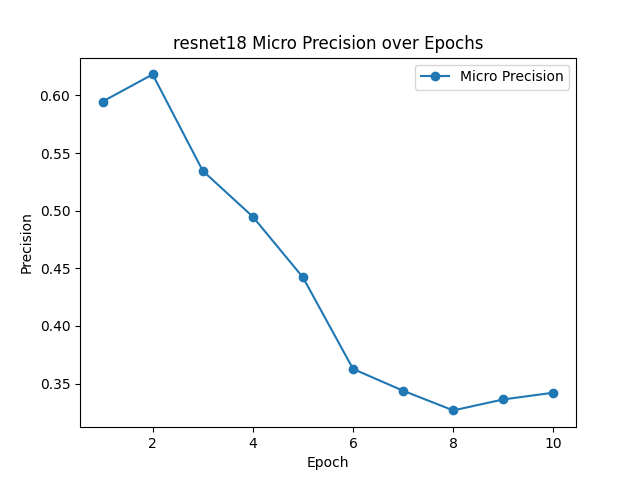


Resnet18 Recall Curve


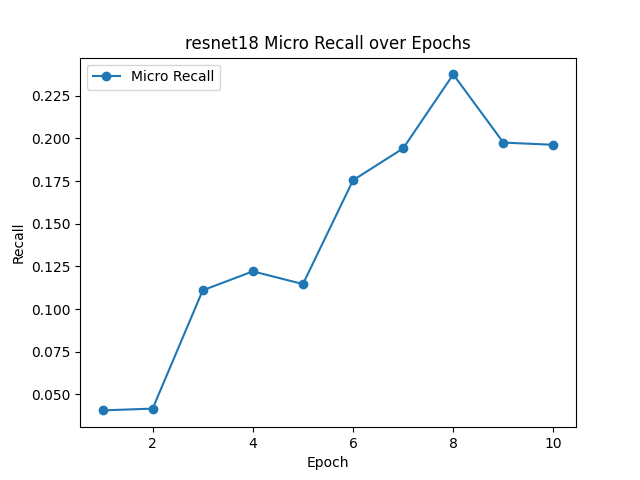


Vgg19 Auroc Curve


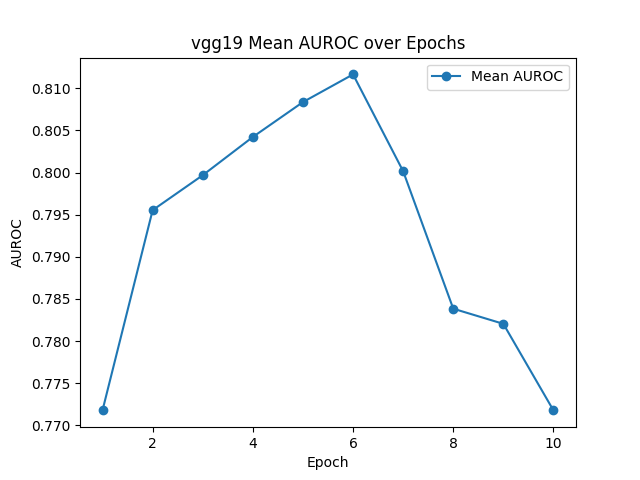


Vgg19 F1 Curve


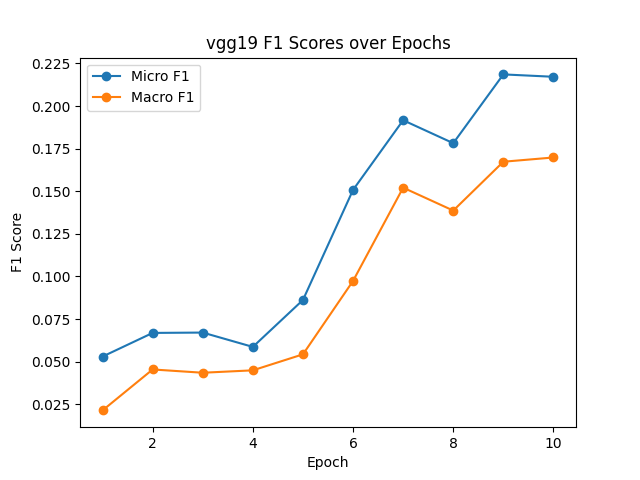


Vgg19 Precision Curve


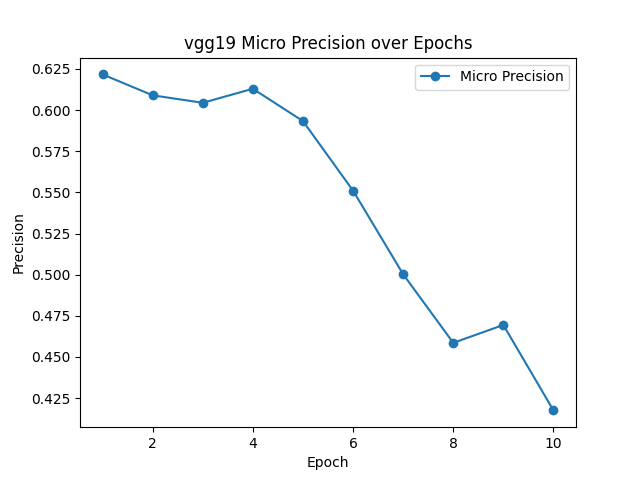


Vgg19 Recall Curve


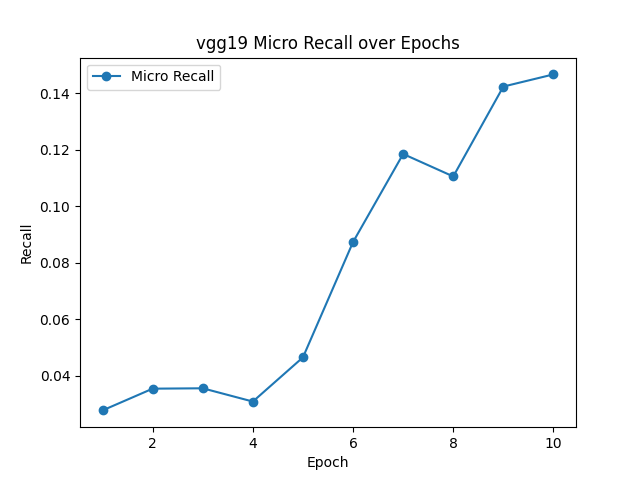


### Case 1: case1_summary
Findings:
- Suggestive evidence of Atelectasis (confidence 0.92)

Context:
- Atelectasis: Partial or complete collapse of lung tissue. [KB]. Caveats: Labels mined from reports; often noisy and ambiguous.

Limitations:
Predictions are probabilistic, labels may contain noise, and clinical correlation is required.

Disclaimer:
This summary is assistive only and not a diagnostic report.

### Case 2: case2_summary
Findings:
- Suggestive evidence of Pleural Effusion (confidence 0.55)

Context:
- Pleural Effusion: Fluid accumulation in the pleural space. [KB]. Caveats: Labeling may miss small effusions.

Limitations:
Predictions are probabilistic, labels may contain noise, and clinical correlation is required.

Disclaimer:
This summary is assistive only and not a diagnostic report.

### Case 3: case3_summary
Findings:
- Suggestive evidence of Pneumonia (confidence 0.33)

Context:
- Pneumonia: Infection causing lung consolidation. [KB]. Caveats: Labels overlap with I

In [ ]:
import os
import pandas as pd
from IPython.display import Image, display

# --- Metrics ---
logs_dir = "../logs"
for file in sorted(os.listdir(logs_dir)):
    if file.endswith(".csv"):
        prefix = file.split("_")[0].upper()
        df = pd.read_csv(os.path.join(logs_dir, file))
        print(f"\n### {prefix} Metrics")
        display(df)

# --- Performance Plots ---
figures_dir = "../report/figures"
for filename in sorted(os.listdir(figures_dir)):
    if filename.endswith(".png") and not filename.startswith("gradcam"):
        print("\n" + filename.replace(".png", "").replace("_", " ").title())
        display(Image(filename=os.path.join(figures_dir, filename)))

# --- Interpretability & GenAI Layer ---
gradcam_dir = "../report/figures/gradcam"
summaries_dir = "../report/rag_summaries"

for i, file in enumerate(sorted(os.listdir(summaries_dir)), 1):
    if file.endswith("_summary.txt"):
        with open(os.path.join(summaries_dir, file), "r") as f:
            summary_text = f.read()
        print(f"\n### Case {i}: {file.replace('.txt','')}")
        print(summary_text)

        # Match Grad-CAM overlays by case ID (case1, case2, case3)
        case_id = file.split("_")[0]  # e.g., "case1"
        for img in sorted(os.listdir(gradcam_dir)):
            if img.startswith(case_id):
                display(Image(filename=os.path.join(gradcam_dir, img)))

## Discussion

Across the representative cases, the interpretability layer highlights both strengths and weaknesses
of the CustomCNN model. In confident predictions, Grad‑CAM overlays align with clinically relevant 
regions, and the RAG summaries provide clear contextual explanations. In borderline cases, overlays
are diffuse and confidence scores reflect uncertainty, showing how the model struggles with ambiguous
inputs. Failure cases demonstrate misfocused Grad‑CAM maps and noisy labels, reinforcing the importance
of clinical correlation.Together, the visual and textual interpretability outputs illustrate how the
GenAI layer communicates model reasoning, uncertainty, and caveats transparently.